In [ ]:
!pip install -q --upgrade transformers==4.56.2 diffusers==0.32.2 datasets==3.6.0

In [ ]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
# Imports

import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio
from IPython.display import display
from diffusers import AutoPipelineForText2Image

In [ ]:
# Sentiment Analysis

sa_pipeline = pipeline("sentiment-analysis", device="cuda")
result1 = sa_pipeline("I love this!")
result2 = sa_pipeline("I'm not so good'")
print(result1)
print(result2)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9998764991760254}]
[{'label': 'NEGATIVE', 'score': 0.9997996687889099}]


In [ ]:
# Named Entity Recognition

ner_pipeline = pipeline("ner", device="cuda")
result = ner_pipeline("I'm Ed Conner, learning Generative AI from HuggingFace")
for entity in result:
  print(entity)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda


{'entity': 'I-PER', 'score': np.float32(0.9992908), 'index': 4, 'word': 'Ed', 'start': 4, 'end': 6}
{'entity': 'I-PER', 'score': np.float32(0.999785), 'index': 5, 'word': 'Conner', 'start': 7, 'end': 13}
{'entity': 'I-MISC', 'score': np.float32(0.8876188), 'index': 10, 'word': 'AI', 'start': 35, 'end': 37}
{'entity': 'I-ORG', 'score': np.float32(0.9940334), 'index': 12, 'word': 'Hu', 'start': 43, 'end': 45}
{'entity': 'I-ORG', 'score': np.float32(0.9370671), 'index': 13, 'word': '##gging', 'start': 45, 'end': 50}
{'entity': 'I-ORG', 'score': np.float32(0.9925109), 'index': 14, 'word': '##F', 'start': 50, 'end': 51}
{'entity': 'I-ORG', 'score': np.float32(0.9837466), 'index': 15, 'word': '##ace', 'start': 51, 'end': 54}


In [ ]:
# Question Answering with Context

q = "What is AI?"
c = "AI is the name of my neighbours dog's"

qna_pipeline = pipeline("question-answering", device="cuda")
result = qna_pipeline(question=q, context=c)
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'score': 0.5243564248085022, 'start': 6, 'end': 37, 'answer': "the name of my neighbours dog's"}


In [ ]:
# Text Summarization

summary_pipeline = pipeline("summarization", device="cuda")

text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""

summary = summary_pipeline(text, max_length=50, min_length=25, do_sample=False)
print(summary[0]['summary_text'])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


 The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .


In [ ]:
# Translation

translator_pipeline = pipeline("translation_en_to_fr", device="cuda")
result = translator_pipeline("Hi Ed, can you speak French")
print(result[0]['translation_text'])

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


Bonjour Ed, pouvez-vous parler français?


In [ ]:
# Classification

classifier_pipeline = pipeline("zero-shot-classification", device="cuda")
result = classifier_pipeline("Hi Ed, do you think the government supports Soccer or AI?", candidate_labels=["technology", "sports", "politics"])
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'sequence': 'Hi Ed, do you think the government supports Soccer or AI?', 'labels': ['sports', 'technology', 'politics'], 'scores': [0.8339316844940186, 0.14802153408527374, 0.018046805635094643]}


In [ ]:
# Text Generation

generate_pipeline = pipeline("text-generation", device="cuda")
result = generate_pipeline("If there's one thing I want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


If there's one thing I want you to remember about using HuggingFace pipelines, it's that they're not perfect. They've gone to great lengths to keep things simple and easy and that's what we're doing here. If you are a developer and want to use HuggingFace on a project, there are a number of options out there that you can choose from. We are at the very beginning of getting to that point. But I will say this: the idea of using HuggingFace is very simple. There are a number of features that you can use for different purposes.

If you are a developer that was born with some sort of "go to" experience, you know, you just go to these different places and you learn from it and you understand its work and understand how you can use it. You can do things like write app templates, but you can't do things like write custom forms. It's just a way to make sure that your application is as simple as possible, to make sure that your application is going to work with all the different ways that you ca

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

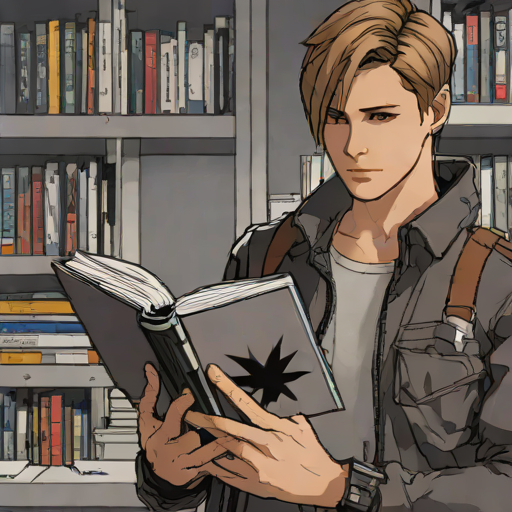

In [ ]:
# Image Generation

img_pipeline = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
img_pipeline.to("cuda")
prompt = "Conner of the game Detroit: Become Human holding Death Note book"
image = img_pipeline(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [ ]:
# Audio Generation

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Jao Chai Banao", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

Device set to use cuda
